In [9]:
import seaborn as sns
import pandas as pd
import re
import numpy as np
from urllib.parse import urlparse

import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

%matplotlib inline

In [10]:
DATA_PATH = './output.csv.gz'
df = pd.read_csv(DATA_PATH)
benign_df = df[df['label'] != 0]
phishing_df = df[df['label'] != 1]
df.head()



,url,label,domain,url_length,domain_length,is_https,is_ip,letter_count,digit_count,special_count,eq_count,qm_count,amp_count,dot_count,dash_count,under_count,letter_ratio,special_ratio,digit_ratio
0,0000111servicehelpdesk.godaddysites.com,0,0000111servicehelpdesk.godaddysites.com,39,39,0,0,30,7,2,0,0,0,2,0,0,0.769231,0.051282,0.179487
1,000011accesswebform.godaddysites.com,0,000011accesswebform.godaddysites.com,36,36,0,0,28,6,2,0,0,0,2,0,0,0.777778,0.055556,0.166667
2,00003.online,0,00003.online,12,12,0,0,6,5,1,0,0,0,1,0,0,0.500000,0.083333,0.416667
3,0009servicedeskowa.godaddysites.com,0,0009servicedeskowa.godaddysites.com,35,35,0,0,29,4,2,0,0,0,2,0,0,0.828571,0.057143,0.114286
4,000n38p.wcomhost.com,0,000n38p.wcomhost.com,20,20,0,0,13,5,2,0,0,0,2,0,0,0.650000,0.100000,0.250000


<function matplotlib.pyplot.show(close=None, block=None)>

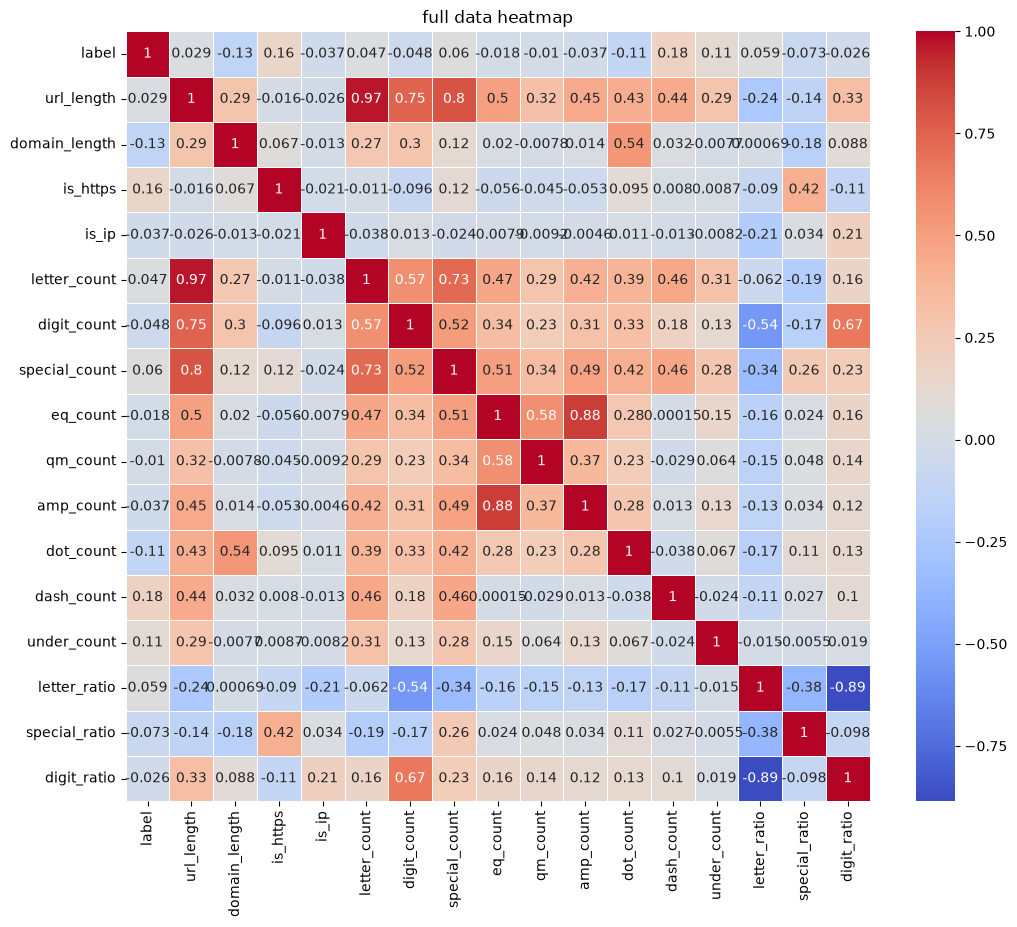

In [11]:
heatmap_df = df.drop(columns=["url", "domain"])

plt.figure(figsize=(12,10))
corr_matrix = heatmap_df.corr()
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', linewidth = 0.5)
plt.title('full data heatmap')
plt.show

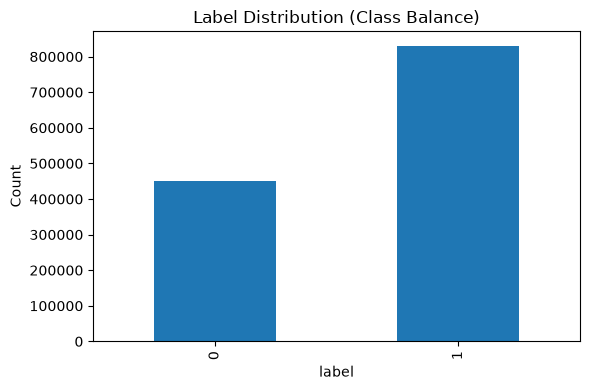

In [12]:
label_counts = df['label'].value_counts().sort_index()
plt.figure(figsize=(6,4))
label_counts.plot(kind='bar')
plt.title('Label Distribution (Class Balance)')
plt.xlabel('label'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

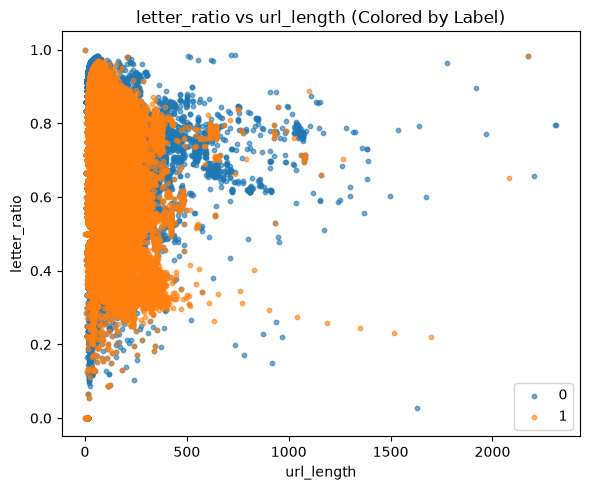

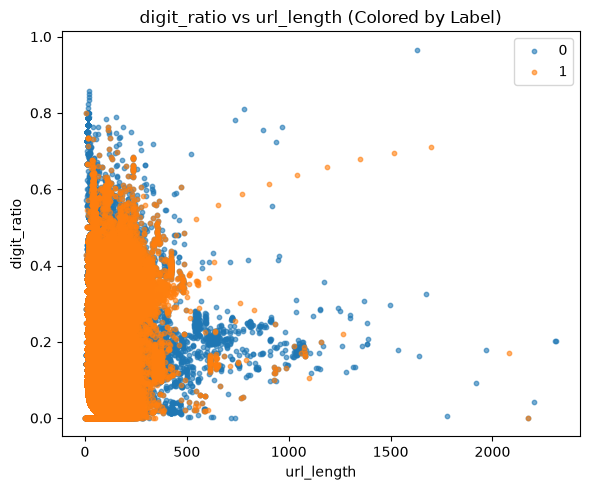

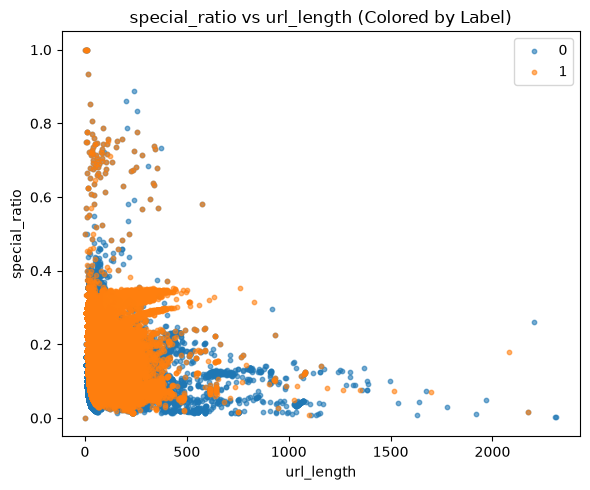

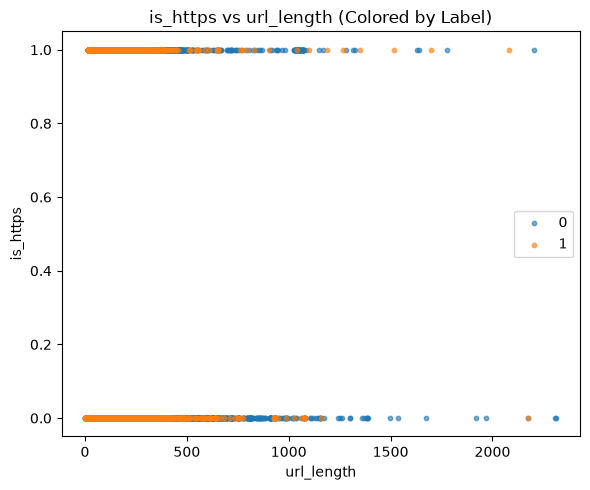

In [18]:
ycol = 'letter_ratio'
xcol = 'url_length'
plt.figure(figsize=(6,5))
for lab, grp in df.groupby('label'):
    plt.scatter(grp[xcol], grp[ycol], s=10, alpha=0.6, label=str(lab))
plt.title(f'{ycol} vs {xcol} (Colored by Label)')
plt.xlabel(xcol); plt.ylabel(ycol)
plt.legend(); plt.tight_layout(); plt.show()

ycol = 'digit_ratio'
xcol = 'url_length'
plt.figure(figsize=(6,5))
for lab, grp in df.groupby('label'):
    plt.scatter(grp[xcol], grp[ycol], s=10, alpha=0.6, label=str(lab))
plt.title(f'{ycol} vs {xcol} (Colored by Label)')
plt.xlabel(xcol); plt.ylabel(ycol)
plt.legend(); plt.tight_layout(); plt.show()

ycol = 'special_ratio'
xcol = 'url_length'
plt.figure(figsize=(6,5))
for lab, grp in df.groupby('label'):
    plt.scatter(grp[xcol], grp[ycol], s=10, alpha=0.6, label=str(lab))
plt.title(f'{ycol} vs {xcol} (Colored by Label)')
plt.xlabel(xcol); plt.ylabel(ycol)
plt.legend(); plt.tight_layout(); plt.show()

ycol = 'is_https'
xcol = 'url_length'
plt.figure(figsize=(6,5))
for lab, grp in df.groupby('label'):
    plt.scatter(grp[xcol], grp[ycol], s=10, alpha=0.6, label=str(lab))
plt.title(f'{ycol} vs {xcol} (Colored by Label)')
plt.xlabel(xcol); plt.ylabel(ycol)
plt.legend(); plt.tight_layout(); plt.show()

In [23]:
df_mean = df.drop(columns=['url', 'domain'])

wow = df_mean.groupby('label').mean()
print(wow)

       url_length  domain_length  is_https     is_ip  letter_count  digit_count  special_count  eq_count  qm_count  amp_count  dot_count  dash_count  \
label                                                                                                                                                  
0       54.079739      21.208128  0.267384  0.002157     40.175236     5.563177       8.336874  0.293656  0.162395   0.170287   2.645926    0.581882   
1       56.763529      17.960004  0.424456  0.000000     43.196129     4.373959       9.192654  0.258481  0.152489   0.109507   2.278035    1.588517   

       under_count  letter_ratio  special_ratio  digit_ratio  
label                                                         
0         0.181723      0.766018       0.169174     0.064738  
1         0.451348      0.778342       0.162025     0.059624  
